In [1]:
# ============================================================
# CELL 1 — SETUP, LOAD DATA & BUILD BASE FEATURES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD ALL DATA
# ============================================================
results          = pd.read_csv('../data/results.csv')
races            = pd.read_csv('../data/races.csv')
drivers          = pd.read_csv('../data/drivers.csv')
constructors     = pd.read_csv('../data/constructors.csv')
pit_stops        = pd.read_csv('../data/pit_stops.csv')
qualifying       = pd.read_csv('../data/qualifying.csv')
driver_standings = pd.read_csv('../data/driver_standings.csv')
circuits         = pd.read_csv('../data/circuits.csv')

print("✅ All CSVs loaded.")

# ============================================================
# CLEAN DATA
# ============================================================
results.replace('\\N', np.nan, inplace=True)
qualifying.replace('\\N', np.nan, inplace=True)
driver_standings.replace('\\N', np.nan, inplace=True)

results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')
results['points']        = pd.to_numeric(results['points'],        errors='coerce')
results['grid']          = pd.to_numeric(results['grid'],          errors='coerce')
results['laps']          = pd.to_numeric(results['laps'],          errors='coerce')
results['position']      = pd.to_numeric(results['position'],      errors='coerce')

print("✅ Data cleaned.")

# ============================================================
# FILTER TO 2021-2024
# ============================================================
modern_races   = races[races['year'].between(2021, 2024)].copy()
modern_raceIds = modern_races['raceId'].tolist()
modern_results = results[results['raceId'].isin(modern_raceIds)].copy()

# Merge race info into results
modern_results = modern_results.merge(
    modern_races[['raceId', 'year', 'round', 'circuitId', 'name']],
    on='raceId', how='left'
)

print(f"\nDataset coverage:")
print(f"  Races   : {len(modern_races)}")
print(f"  Results : {len(modern_results)}")
print(f"  Years   : {sorted(modern_results['year'].unique())}")

# ============================================================
# TARGET VARIABLE
# ============================================================
modern_results['is_winner'] = (
    modern_results['positionOrder'] == 1
).astype(int)

total        = len(modern_results)
winners      = modern_results['is_winner'].sum()
non_winners  = total - winners
win_pct      = (winners / total) * 100

print(f"\nTarget variable — is_winner:")
print(f"  Winners (1)     : {winners}  ({win_pct:.1f}%)")
print(f"  Non-winners (0) : {non_winners}  ({100-win_pct:.1f}%)")
print(f"  Base rate       : 1 winner per race = ~5% positive class")

# ============================================================
# BASE FEATURE 1 — GRID POSITION
# ============================================================
modern_results['grid'] = modern_results['grid'].replace(0, 20)
modern_results['grid'] = modern_results['grid'].fillna(20)

# ============================================================
# BASE FEATURE 2 — DRIVER WIN RATE AT CIRCUIT
# ============================================================
circuit_wins = modern_results.groupby(
    ['driverId', 'circuitId']
).agg(
    races_at_circuit = ('raceId', 'count'),
    wins_at_circuit  = ('is_winner', 'sum')
).reset_index()

circuit_wins['win_rate_at_circuit'] = (
    circuit_wins['wins_at_circuit'] /
    circuit_wins['races_at_circuit']
)

modern_results = modern_results.merge(
    circuit_wins[['driverId', 'circuitId', 'win_rate_at_circuit']],
    on=['driverId', 'circuitId'], how='left'
)
modern_results['win_rate_at_circuit'] = (
    modern_results['win_rate_at_circuit'].fillna(0)
)

# ============================================================
# BASE FEATURE 3 — CONSTRUCTOR AVERAGE POINTS PER RACE
# ============================================================
constructor_avg = (
    modern_results.groupby('constructorId')['points']
    .mean()
    .reset_index()
)
constructor_avg.columns = ['constructorId', 'constructor_avg_points']

modern_results = modern_results.merge(
    constructor_avg, on='constructorId', how='left'
)
modern_results['constructor_avg_points'] = (
    modern_results['constructor_avg_points'].fillna(0)
)

# ============================================================
# BASE FEATURE 4 — DRIVER AVERAGE POINTS PER RACE
# ============================================================
driver_avg = (
    modern_results.groupby('driverId')['points']
    .mean()
    .reset_index()
)
driver_avg.columns = ['driverId', 'driver_avg_points']

modern_results = modern_results.merge(
    driver_avg, on='driverId', how='left'
)
modern_results['driver_avg_points'] = (
    modern_results['driver_avg_points'].fillna(0)
)

# ============================================================
# SUMMARY
# ============================================================
print(f"\nBase features built:")
print(f"  grid                    : qualifying / grid position")
print(f"  win_rate_at_circuit     : driver historical win % at this circuit")
print(f"  constructor_avg_points  : team average points per race")
print(f"  driver_avg_points       : driver average points per race")
print(f"\nFinal dataset shape : {modern_results.shape}")
print(f"\n✅ Cell 1 complete - Base features ready.")

✅ All CSVs loaded.
✅ Data cleaned.

Dataset coverage:
  Races   : 90
  Results : 1799
  Years   : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Target variable — is_winner:
  Winners (1)     : 90  (5.0%)
  Non-winners (0) : 1709  (95.0%)
  Base rate       : 1 winner per race = ~5% positive class

Base features built:
  grid                    : qualifying / grid position
  win_rate_at_circuit     : driver historical win % at this circuit
  constructor_avg_points  : team average points per race
  driver_avg_points       : driver average points per race

Final dataset shape : (1799, 26)

✅ Cell 1 complete - Base features ready.


In [2]:
# ============================================================
# CELL 2 — ADVANCED FEATURE ENGINEERING
# ============================================================

# ============================================================
# FEATURE 5 — DRIVER FORM (rolling avg points last 3 races)
# ============================================================
# Sort by driver, year, round so rolling is chronological
modern_results = modern_results.sort_values(
    ['driverId', 'year', 'round']
).reset_index(drop=True)

modern_results['driver_form_3'] = (
    modern_results.groupby('driverId')['points']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    .fillna(0)
)

print("✅ Feature 5 done - driver_form_3 (rolling 3 race avg points)")

# ============================================================
# FEATURE 6 — DRIVER FORM (rolling avg points last 5 races)
# ============================================================
modern_results['driver_form_5'] = (
    modern_results.groupby('driverId')['points']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)

print("✅ Feature 6 done - driver_form_5 (rolling 5 race avg points)")

# ============================================================
# FEATURE 7 — DRIVER RECENT WIN RATE (last 5 races)
# ============================================================
modern_results['recent_win_rate'] = (
    modern_results.groupby('driverId')['is_winner']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    .fillna(0)
)

print("✅ Feature 7 done - recent_win_rate (rolling 5 race win rate)")

# ============================================================
# FEATURE 8 — CONSTRUCTOR FORM (rolling avg points last 3 races)
# ============================================================
# Use sum of both drivers points per race for constructor form
constructor_race_pts = (
    modern_results.groupby(['constructorId', 'raceId'])['points']
    .sum()
    .reset_index()
)
constructor_race_pts.columns = ['constructorId', 'raceId',
                                 'constructor_race_total_pts']

modern_results = modern_results.merge(
    constructor_race_pts, on=['constructorId', 'raceId'], how='left'
)

modern_results = modern_results.sort_values(
    ['constructorId', 'year', 'round']
).reset_index(drop=True)

modern_results['constructor_form_3'] = (
    modern_results.groupby('constructorId')['constructor_race_total_pts']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    .fillna(0)
)

print("✅ Feature 8 done - constructor_form_3 (rolling 3 race team points)")

# ============================================================
# FEATURE 9 — GRID POSITION SQUARED
# (non-linear relationship — P1 advantage is exponentially bigger)
# ============================================================
modern_results['grid_squared'] = modern_results['grid'] ** 2

print("✅ Feature 9 done - grid_squared")

# ============================================================
# FEATURE 10 — IS FRONT ROW (grid 1 or 2)
# ============================================================
modern_results['is_front_row'] = (
    modern_results['grid'] <= 2
).astype(int)

print("✅ Feature 10 done - is_front_row")

# ============================================================
# FEATURE 11 — IS POLE POSITION (grid == 1)
# ============================================================
modern_results['is_pole'] = (
    modern_results['grid'] == 1
).astype(int)

print("✅ Feature 11 done - is_pole")

# ============================================================
# FEATURE 12 — DRIVER CHAMPIONSHIP POSITION AT THAT POINT
# ============================================================
driver_standings.replace('\\N', np.nan, inplace=True)
driver_standings['position'] = pd.to_numeric(
    driver_standings['position'], errors='coerce'
)
driver_standings['points'] = pd.to_numeric(
    driver_standings['points'], errors='coerce'
)

# Get standing position per driver per race
standings_per_race = driver_standings[
    ['raceId', 'driverId', 'position', 'points']
].copy()
standings_per_race.columns = [
    'raceId', 'driverId',
    'championship_position',
    'championship_points'
]

modern_results = modern_results.merge(
    standings_per_race, on=['raceId', 'driverId'], how='left'
)
modern_results['championship_position'] = (
    modern_results['championship_position'].fillna(20)
)
modern_results['championship_points'] = (
    modern_results['championship_points'].fillna(0)
)

print("✅ Feature 12 done - championship_position + championship_points")

# ============================================================
# FEATURE 13 — DNF RATE (driver reliability)
# ============================================================
# statusId 1 = Finished, everything else = DNF
results_all = pd.read_csv('../data/results.csv')
results_all.replace('\\N', np.nan, inplace=True)
results_all['statusId'] = pd.to_numeric(
    results_all['statusId'], errors='coerce'
)

dnf_rate = results_all.groupby('driverId').apply(
    lambda x: (x['statusId'] != 1).sum() / len(x)
).reset_index()
dnf_rate.columns = ['driverId', 'dnf_rate']

modern_results = modern_results.merge(
    dnf_rate, on='driverId', how='left'
)
modern_results['dnf_rate'] = modern_results['dnf_rate'].fillna(0)

print("✅ Feature 13 done - dnf_rate (driver reliability score)")

# ============================================================
# FEATURE 14 — ROUND NUMBER (race number in season)
# (early season vs late season dynamics)
# ============================================================
# Already in modern_results as 'round'
print("✅ Feature 14 done - round (already in dataset)")

# ============================================================
# FINAL FEATURE SET SUMMARY
# ============================================================
feature_cols = [
    'grid',
    'grid_squared',
    'is_pole',
    'is_front_row',
    'driver_avg_points',
    'driver_form_3',
    'driver_form_5',
    'recent_win_rate',
    'win_rate_at_circuit',
    'constructor_avg_points',
    'constructor_form_3',
    'championship_position',
    'championship_points',
    'dnf_rate',
    'round',
]

print(f"\n{'='*50}")
print(f"  FINAL FEATURE SET ({len(feature_cols)} features)")
print(f"{'='*50}")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {f}")

# Check for nulls in features
null_counts = modern_results[feature_cols].isnull().sum()
if null_counts.sum() == 0:
    print(f"\n✅ No nulls in any feature column.")
else:
    print(f"\n⚠️  Nulls found:")
    print(null_counts[null_counts > 0])

print(f"\nFinal dataset shape : {modern_results.shape}")
print(f"\n✅ Cell 2 complete - All {len(feature_cols)} features ready.")

✅ Feature 5 done - driver_form_3 (rolling 3 race avg points)
✅ Feature 6 done - driver_form_5 (rolling 5 race avg points)
✅ Feature 7 done - recent_win_rate (rolling 5 race win rate)
✅ Feature 8 done - constructor_form_3 (rolling 3 race team points)
✅ Feature 9 done - grid_squared
✅ Feature 10 done - is_front_row
✅ Feature 11 done - is_pole
✅ Feature 12 done - championship_position + championship_points
✅ Feature 13 done - dnf_rate (driver reliability score)
✅ Feature 14 done - round (already in dataset)

  FINAL FEATURE SET (15 features)
   1. grid
   2. grid_squared
   3. is_pole
   4. is_front_row
   5. driver_avg_points
   6. driver_form_3
   7. driver_form_5
   8. recent_win_rate
   9. win_rate_at_circuit
  10. constructor_avg_points
  11. constructor_form_3
  12. championship_position
  13. championship_points
  14. dnf_rate
  15. round

✅ No nulls in any feature column.

Final dataset shape : (1799, 37)

✅ Cell 2 complete - All 15 features ready.


Train set (2021-2023) : 1320 rows | 66 winners
Test set  (2024)      : 479 rows  | 24 winners
Features              : 15

Class imbalance ratio : 19:1 (non-winner:winner)

  Training XGBoost...
  XGBoost trained in 2.11s

  Training Random Forest...
  Random Forest trained in 0.54s

  MODEL EVALUATION — Test Set 2024
               Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                        
XGBoost          0.9603     0.5862  0.7083    0.6415   0.9750
Random Forest    0.9499     0.5000  0.6250    0.5556   0.9746


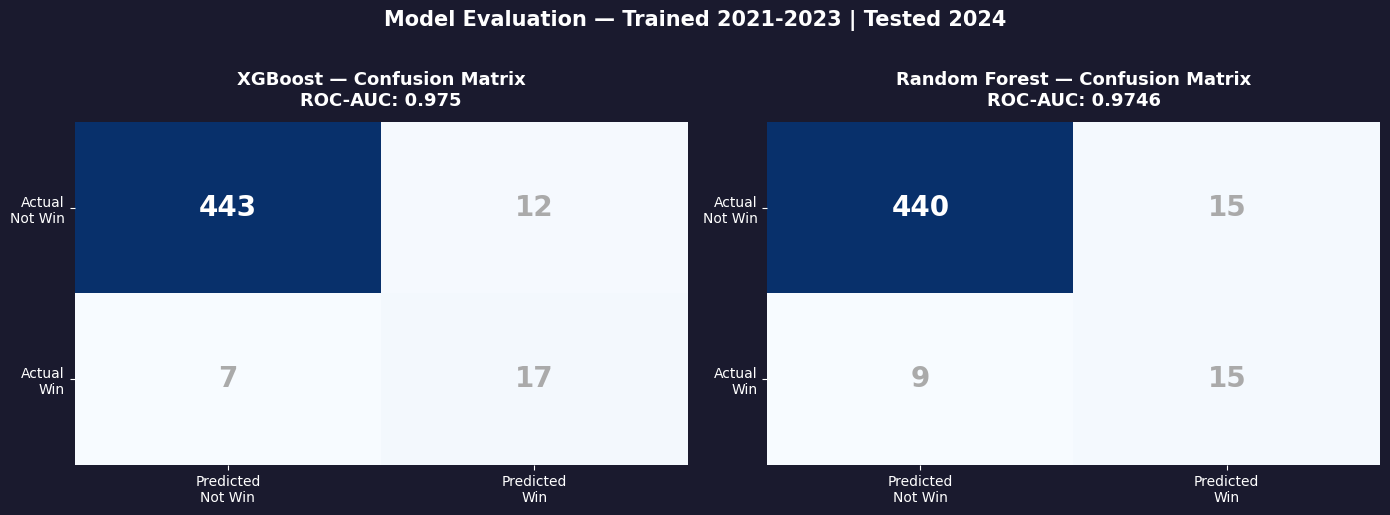


✅ Cell 3 complete - Both models trained and evaluated.

Quick summary:
  XGBoost ROC-AUC      : 0.975
  Random Forest ROC-AUC: 0.9746
  Better model         : XGBoost


In [3]:
# ============================================================
# CELL 3 — TRAIN XGBOOST & RANDOM FOREST ON 2021-2023
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              classification_report)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import time

# ============================================================
# DEFINE FEATURE COLUMNS
# ============================================================
feature_cols = [
    'grid',
    'grid_squared',
    'is_pole',
    'is_front_row',
    'driver_avg_points',
    'driver_form_3',
    'driver_form_5',
    'recent_win_rate',
    'win_rate_at_circuit',
    'constructor_avg_points',
    'constructor_form_3',
    'championship_position',
    'championship_points',
    'dnf_rate',
    'round',
]

target_col = 'is_winner'

# ============================================================
# TRAIN / TEST SPLIT
# Train: 2021-2023  |  Test: 2024
# ============================================================
train_df = modern_results[modern_results['year'].between(2021, 2023)].copy()
test_df  = modern_results[modern_results['year'] == 2024].copy()

X_train = train_df[feature_cols].fillna(0)
y_train = train_df[target_col]

X_test  = test_df[feature_cols].fillna(0)
y_test  = test_df[target_col]

print(f"Train set (2021-2023) : {len(X_train)} rows | {y_train.sum()} winners")
print(f"Test set  (2024)      : {len(X_test)} rows  | {y_test.sum()} winners")
print(f"Features              : {len(feature_cols)}")

# ============================================================
# SCALE WEIGHTS — handle class imbalance
# ~5% positive class (1 winner per 20 drivers)
# ============================================================
scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum())
print(f"\nClass imbalance ratio : {scale_pos_weight}:1 (non-winner:winner)")

# ============================================================
# MODEL 1 — XGBOOST
# ============================================================
print(f"\n{'='*50}")
print(f"  Training XGBoost...")
print(f"{'='*50}")

xgb_start = time.time()

xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = 42,
    verbosity         = 0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_time = time.time() - xgb_start
print(f"  XGBoost trained in {xgb_time:.2f}s")

# XGBoost predictions
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred       = xgb_model.predict(X_test)

# ============================================================
# MODEL 2 — RANDOM FOREST
# ============================================================
print(f"\n{'='*50}")
print(f"  Training Random Forest...")
print(f"{'='*50}")

rf_start = time.time()

rf_model = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 8,
    min_samples_leaf = 4,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,
)

rf_model.fit(X_train, y_train)

rf_time = time.time() - rf_start
print(f"  Random Forest trained in {rf_time:.2f}s")

# Random Forest predictions
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred       = rf_model.predict(X_test)

# ============================================================
# EVALUATE BOTH MODELS
# ============================================================
def evaluate_model(name, y_true, y_pred, y_proba):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_proba)
    return {
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1 Score' : round(f1,   4),
        'ROC-AUC'  : round(auc,  4),
    }

xgb_metrics = evaluate_model(
    'XGBoost', y_test, xgb_pred, xgb_pred_proba
)
rf_metrics  = evaluate_model(
    'Random Forest', y_test, rf_pred, rf_pred_proba
)

metrics_df = pd.DataFrame([xgb_metrics, rf_metrics])
metrics_df = metrics_df.set_index('Model')

print(f"\n{'='*55}")
print(f"  MODEL EVALUATION — Test Set 2024")
print(f"{'='*55}")
print(metrics_df.to_string())

# ============================================================
# CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, y_pred, name, color in zip(
    axes,
    [xgb_pred, rf_pred],
    ['XGBoost', 'Random Forest'],
    ['#3671C6', '#FF8000']
):
    ax.set_facecolor('#1a1a2e')
    cm = confusion_matrix(y_test, y_pred)

    im = ax.imshow(cm, cmap='Blues', aspect='auto')

    # Labels
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    fontsize=20, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2
                    else '#aaaaaa')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nNot Win', 'Predicted\nWin'],
                        color='white', fontsize=10)
    ax.set_yticklabels(['Actual\nNot Win', 'Actual\nWin'],
                        color='white', fontsize=10)
    ax.set_title(f'{name} — Confusion Matrix\n'
                 f'ROC-AUC: {evaluate_model(name, y_test, y_pred, xgb_pred_proba if name == "XGBoost" else rf_pred_proba)["ROC-AUC"]}',
                 fontsize=13, fontweight='bold',
                 color='white', pad=12)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(colors='white')

fig.suptitle('Model Evaluation — Trained 2021-2023 | Tested 2024',
             fontsize=15, fontweight='bold',
             color='white', y=1.02)

plt.tight_layout()
plt.savefig('model_confusion_matrices.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# ============================================================
# SAVE MODELS & METRICS FOR CELL 4
# ============================================================
test_df = test_df.copy()
test_df['xgb_proba']  = xgb_pred_proba
test_df['xgb_pred']   = xgb_pred
test_df['rf_proba']   = rf_pred_proba
test_df['rf_pred']    = rf_pred

print(f"\n✅ Cell 3 complete - Both models trained and evaluated.")
print(f"\nQuick summary:")
print(f"  XGBoost ROC-AUC      : {xgb_metrics['ROC-AUC']}")
print(f"  Random Forest ROC-AUC: {rf_metrics['ROC-AUC']}")
better = 'XGBoost' if xgb_metrics['ROC-AUC'] >= rf_metrics['ROC-AUC'] else 'Random Forest'
print(f"  Better model         : {better}")

  RACE-BY-RACE PREDICTIONS vs ACTUAL — 2024 SEASON
  Rd   Race                           Actual Winner          XGB Pick               RF Pick
  ------------------------------------------------------------------------------
  1    Bahrain Grand Prix             Max Verstappen         ✅ Max Verstappen       ✅ Max Verstappen
  2    Saudi Arabian Grand Prix       Max Verstappen         ✅ Max Verstappen       ✅ Max Verstappen
  3    Australian Grand Prix          Carlos Sainz           ❌ Max Verstappen       ❌ Max Verstappen
  4    Japanese Grand Prix            Max Verstappen         ✅ Max Verstappen       ✅ Max Verstappen
  5    Chinese Grand Prix             Max Verstappen         ✅ Max Verstappen       ✅ Max Verstappen
  6    Miami Grand Prix               Lando Norris           ❌ Max Verstappen       ❌ Max Verstappen
  7    Emilia Romagna Grand Prix      Max Verstappen         ✅ Max Verstappen       ✅ Max Verstappen
  8    Monaco Grand Prix              Charles Leclerc        ✅ Charle

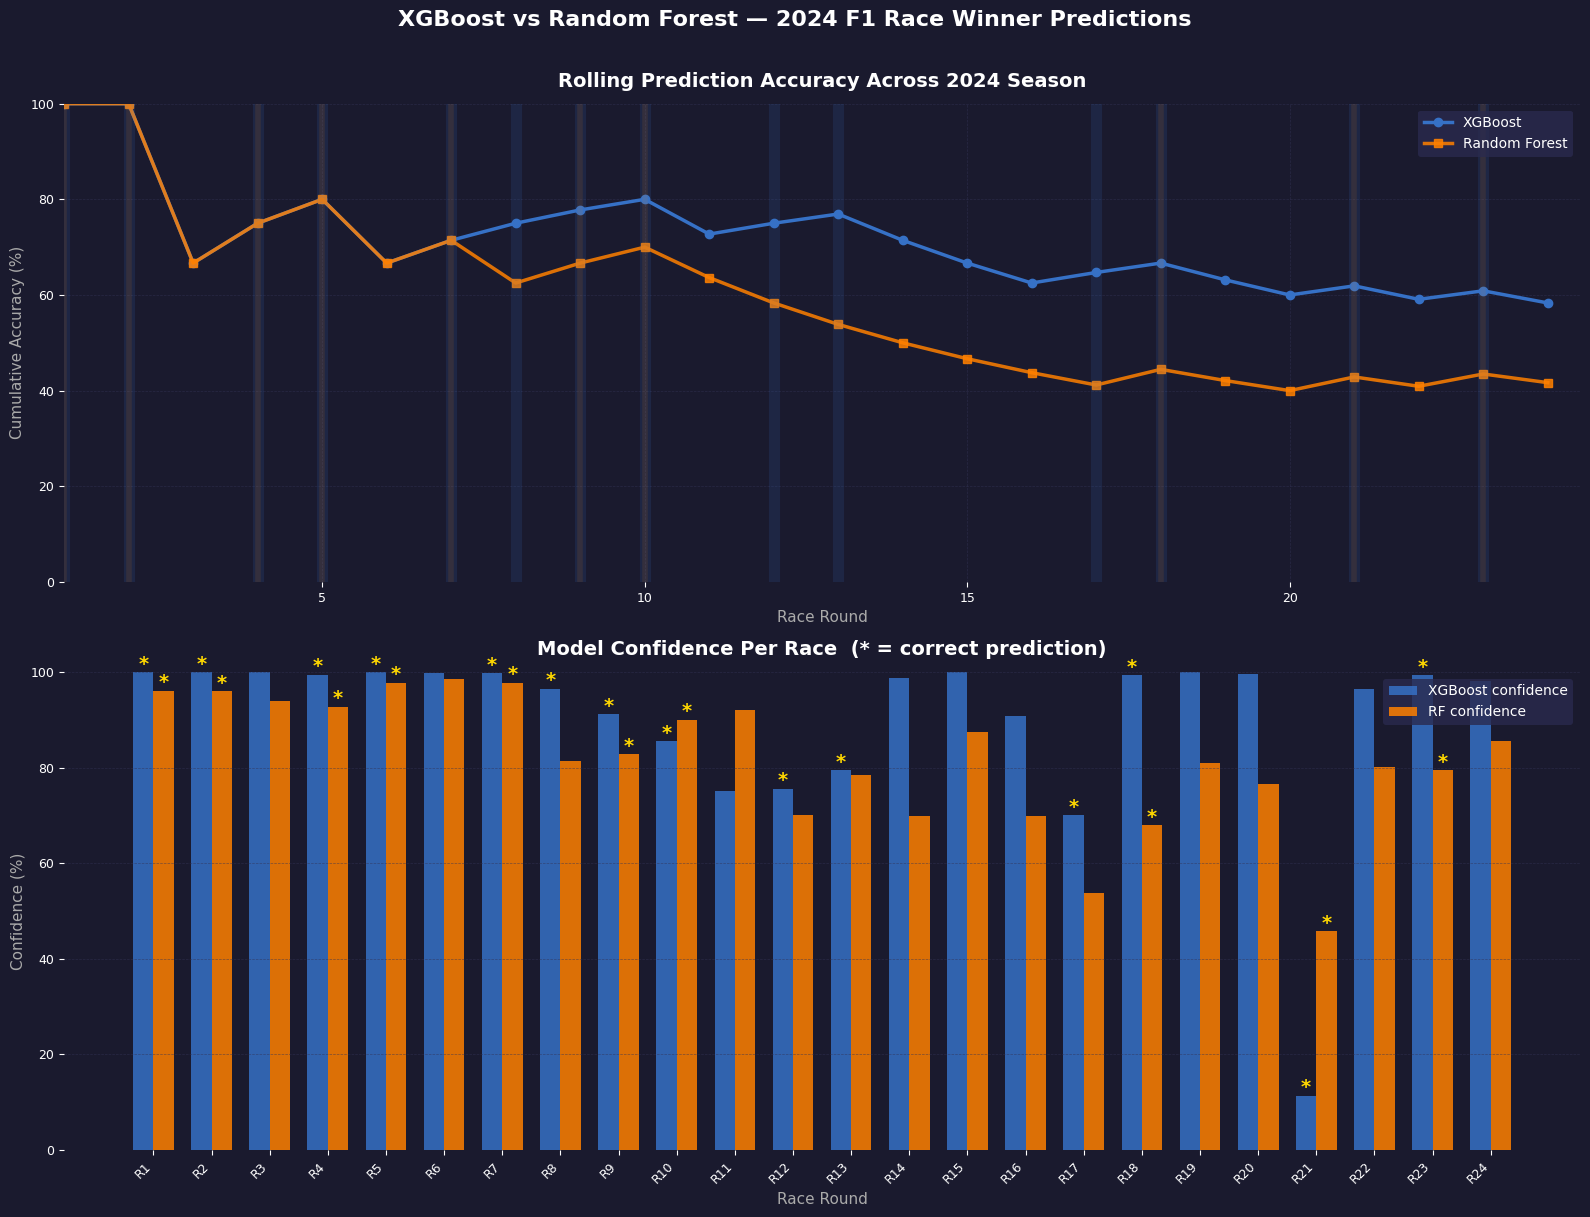


✅ predictions_2024.csv saved.

✅ Cell 4 complete - Predictions vs Actual done.


In [4]:
# ============================================================
# CELL 4 — PREDICTIONS VS ACTUAL 2024 RACE RESULTS
# ============================================================

# ============================================================
# MERGE DRIVER NAMES INTO TEST SET
# ============================================================
test_df = test_df.merge(
    drivers[['driverId', 'forename', 'surname']],
    on='driverId', how='left'
)
test_df['driver_name'] = test_df['forename'] + ' ' + test_df['surname']

test_df = test_df.merge(
    constructors[['constructorId', 'name']],
    on='constructorId', how='left'
)
test_df.rename(columns={'name': 'team_name'}, inplace=True)

test_df = test_df.merge(
    races[['raceId', 'name']].rename(columns={'name': 'race_name'}),
    on='raceId', how='left'
)

# ============================================================
# PER RACE — MODEL PREDICTED WINNER vs ACTUAL WINNER
# ============================================================
race_predictions = []

for race_id in test_df['raceId'].unique():
    race = test_df[test_df['raceId'] == race_id].copy()

    actual_winner = race[race['is_winner'] == 1]['driver_name'].values
    actual_winner = actual_winner[0] if len(actual_winner) > 0 else 'Unknown'

    # XGBoost top pick
    xgb_pick_idx  = race['xgb_proba'].idxmax()
    xgb_pick      = race.loc[xgb_pick_idx, 'driver_name']
    xgb_conf      = race.loc[xgb_pick_idx, 'xgb_proba']

    # Random Forest top pick
    rf_pick_idx   = race['rf_proba'].idxmax()
    rf_pick       = race.loc[rf_pick_idx, 'driver_name']
    rf_conf       = race.loc[rf_pick_idx, 'rf_proba']

    race_predictions.append({
        'raceId'        : race_id,
        'race_name'     : race['race_name'].iloc[0],
        'round'         : race['round'].iloc[0],
        'actual_winner' : actual_winner,
        'xgb_pick'      : xgb_pick,
        'xgb_conf'      : round(xgb_conf, 3),
        'xgb_correct'   : int(xgb_pick == actual_winner),
        'rf_pick'       : rf_pick,
        'rf_conf'       : round(rf_conf, 3),
        'rf_correct'    : int(rf_pick == actual_winner),
    })

pred_df = pd.DataFrame(race_predictions).sort_values('round')

# ============================================================
# PRINT RACE BY RACE RESULTS
# ============================================================
xgb_total_correct = pred_df['xgb_correct'].sum()
rf_total_correct  = pred_df['rf_correct'].sum()
total_races       = len(pred_df)

print(f"{'='*80}")
print(f"  RACE-BY-RACE PREDICTIONS vs ACTUAL — 2024 SEASON")
print(f"{'='*80}")
print(f"  {'Rd':<4} {'Race':<30} {'Actual Winner':<22} {'XGB Pick':<22} {'RF Pick'}")
print(f"  {'-'*78}")

for _, row in pred_df.iterrows():
    xgb_tick = '✅' if row['xgb_correct'] else '❌'
    rf_tick  = '✅' if row['rf_correct']  else '❌'
    print(
        f"  {int(row['round']):<4} "
        f"{row['race_name'][:28]:<30} "
        f"{row['actual_winner'][:20]:<22} "
        f"{xgb_tick} {row['xgb_pick'][:18]:<20} "
        f"{rf_tick} {row['rf_pick'][:18]}"
    )

print(f"\n{'='*80}")
print(f"  TOTAL CORRECT PREDICTIONS (2024 — {total_races} races)")
print(f"  XGBoost       : {xgb_total_correct}/{total_races} "
      f"({xgb_total_correct/total_races*100:.1f}%)")
print(f"  Random Forest : {rf_total_correct}/{total_races} "
      f"({rf_total_correct/total_races*100:.1f}%)")
print(f"{'='*80}")

# ============================================================
# PLOT 1 — CORRECT PREDICTIONS PER RACE (rolling accuracy)
# ============================================================
pred_df['xgb_cumulative'] = pred_df['xgb_correct'].cumsum()
pred_df['rf_cumulative']  = pred_df['rf_correct'].cumsum()
pred_df['xgb_rolling_acc'] = (
    pred_df['xgb_cumulative'] / (pred_df['round'])
) * 100
pred_df['rf_rolling_acc'] = (
    pred_df['rf_cumulative'] / (pred_df['round'])
) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#1a1a2e')

# --- Top: Rolling accuracy across season ---
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')

ax1.plot(pred_df['round'], pred_df['xgb_rolling_acc'],
         color='#3671C6', linewidth=2.5, marker='o',
         markersize=6, label='XGBoost')
ax1.plot(pred_df['round'], pred_df['rf_rolling_acc'],
         color='#FF8000', linewidth=2.5, marker='s',
         markersize=6, label='Random Forest', alpha=0.85)

# Correct prediction markers
for _, row in pred_df.iterrows():
    if row['xgb_correct']:
        ax1.axvline(x=row['round'], color='#3671C6',
                    alpha=0.15, linewidth=8)
    if row['rf_correct']:
        ax1.axvline(x=row['round'], color='#FF8000',
                    alpha=0.10, linewidth=4)

ax1.set_title('Rolling Prediction Accuracy Across 2024 Season',
              fontsize=14, fontweight='bold', color='white', pad=12)
ax1.set_xlabel('Race Round', fontsize=11, color='#aaaaaa')
ax1.set_ylabel('Cumulative Accuracy (%)', fontsize=11, color='#aaaaaa')
ax1.tick_params(colors='white', labelsize=9)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax1.grid(color='#333355', linestyle='--', linewidth=0.5, alpha=0.6)
ax1.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=10)
ax1.set_xlim(1, total_races + 0.5)
ax1.set_ylim(0, 100)

# --- Bottom: Confidence scores per race ---
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

width = 0.35
x     = np.arange(len(pred_df))

bars1 = ax2.bar(x - width/2, pred_df['xgb_conf'] * 100,
                width, color='#3671C6', alpha=0.85,
                edgecolor='none', label='XGBoost confidence')
bars2 = ax2.bar(x + width/2, pred_df['rf_conf'] * 100,
                width, color='#FF8000', alpha=0.85,
                edgecolor='none', label='RF confidence')

# Mark correct predictions with a star
for i, (_, row) in enumerate(pred_df.iterrows()):
    if row['xgb_correct']:
        ax2.text(i - width/2, row['xgb_conf'] * 100 + 0.5,
                 '*', ha='center', color='#FFD700',
                 fontsize=14, fontweight='bold')
    if row['rf_correct']:
        ax2.text(i + width/2, row['rf_conf'] * 100 + 0.5,
                 '*', ha='center', color='#FFD700',
                 fontsize=14, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(
    [f"R{int(r)}" for r in pred_df['round']],
    rotation=45, ha='right', fontsize=8, color='white'
)
ax2.set_title('Model Confidence Per Race  (* = correct prediction)',
              fontsize=14, fontweight='bold', color='white', pad=12)
ax2.set_xlabel('Race Round', fontsize=11, color='#aaaaaa')
ax2.set_ylabel('Confidence (%)', fontsize=11, color='#aaaaaa')
ax2.tick_params(colors='white', labelsize=9)
ax2.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax2.grid(axis='y', color='#333355', linestyle='--',
         linewidth=0.5, alpha=0.6)
ax2.legend(facecolor='#2a2a4e', edgecolor='none',
           labelcolor='white', fontsize=10)
ax2.set_ylim(0, 100)

fig.suptitle('XGBoost vs Random Forest — 2024 F1 Race Winner Predictions',
             fontsize=16, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig('predictions_vs_actual_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

# ============================================================
# SAVE PREDICTIONS TO CSV
# ============================================================
pred_df.to_csv('predictions_2024.csv', index=False)
print("\n✅ predictions_2024.csv saved.")
print(f"\n✅ Cell 4 complete - Predictions vs Actual done.")

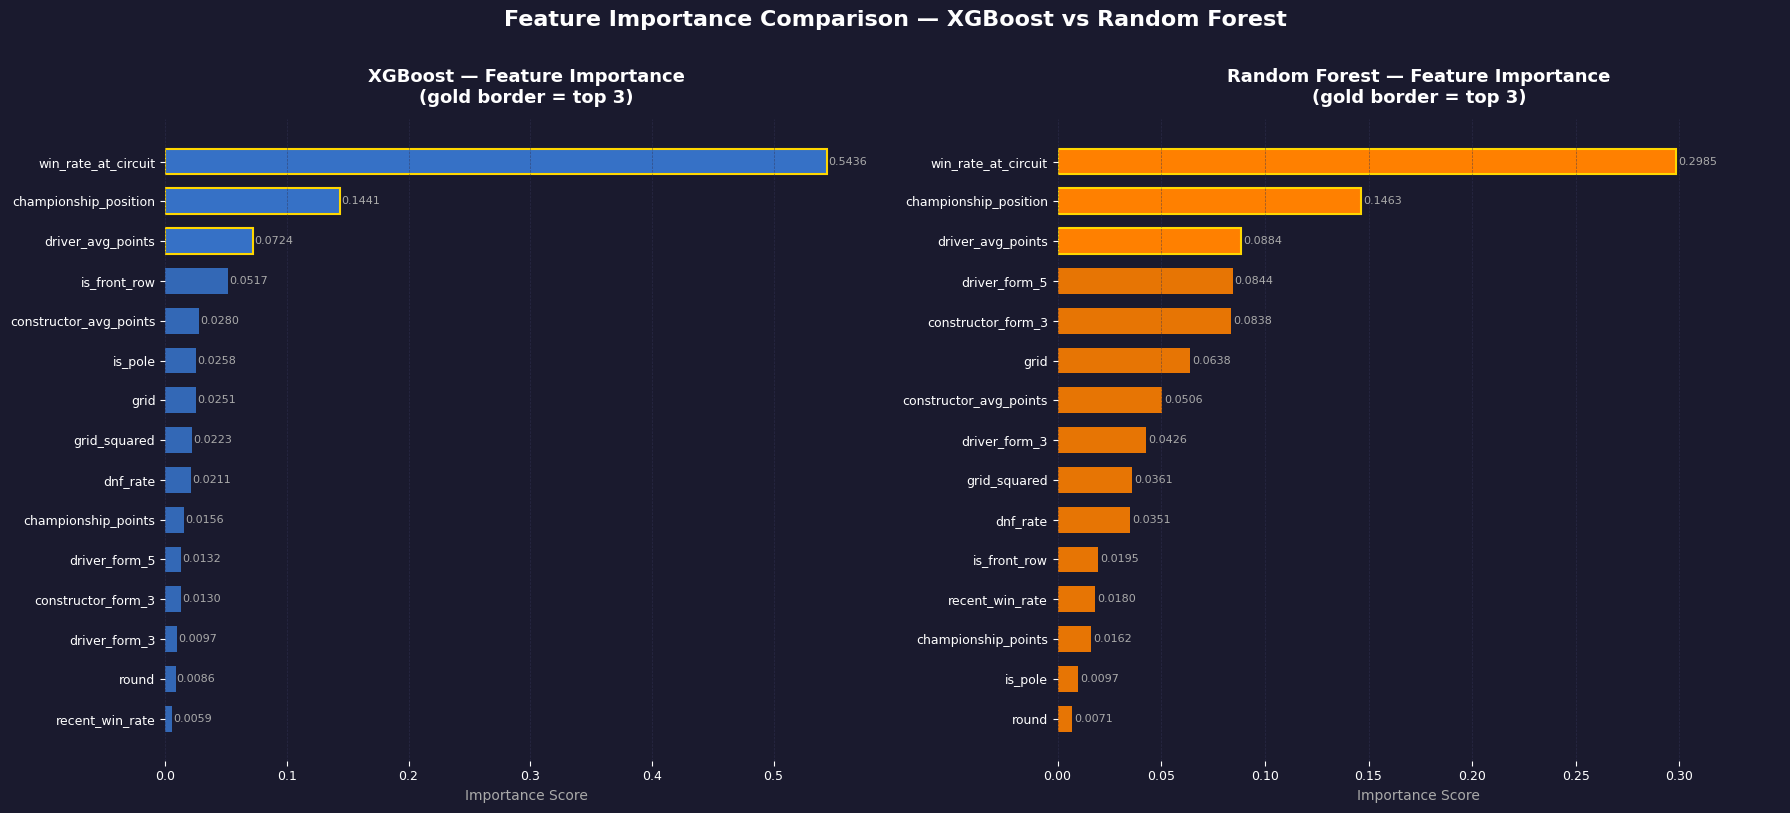

✅ Feature importance chart saved.


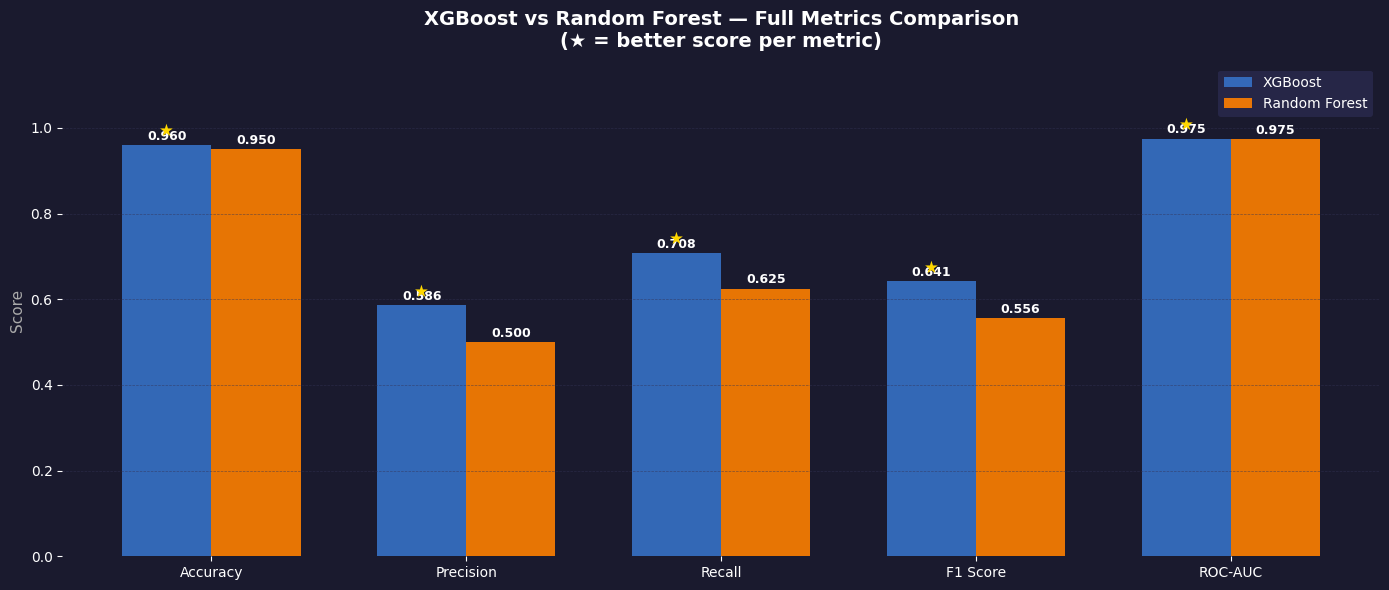

✅ Model metrics comparison chart saved.

╔══════════════════════════════════════════════════════════════════╗
║        F1 ML RACE PREDICTION - PART 3 COMPLETE                  ║
║        Train: 2021-2023  |  Test: 2024  |  06 Apr 2026          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL SETUP                                                     ║
║  Target variable  : Race winner (is_winner = 1)                 ║
║  Features used    : 15                                          ║
║  Training seasons : 2021, 2022, 2023                            ║
║  Test season      : 2024 (24 races)                           ║
║                                                                  ║
║  XGBOOST RESULTS                                                 ║
║  Accuracy         : 0.9603                                  ║
║  Precision        : 0.5862                                  ║
║  Recall  

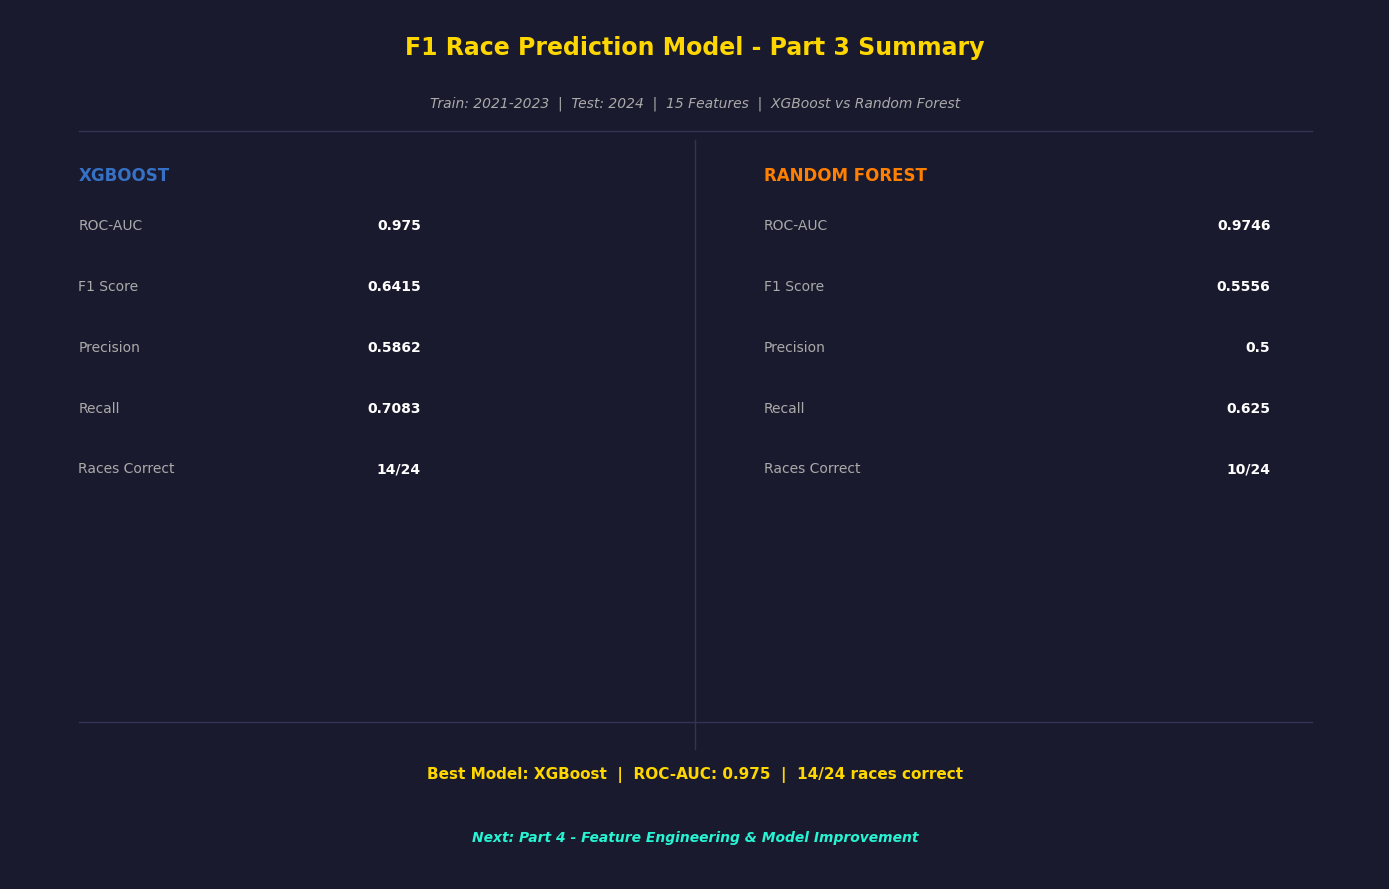

✅ Cell 5 complete - Summary card saved.

PART 3 FULLY COMPLETE. Next -> 04_model_improvement


In [5]:
# ============================================================
# CELL 5 — FEATURE IMPORTANCE + MODEL COMPARISON + SUMMARY
# ============================================================

from datetime import datetime

# ============================================================
# FEATURE IMPORTANCE — XGBOOST
# ============================================================
xgb_importance = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

# ============================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# ============================================================
rf_importance = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

# ============================================================
# PLOT 1 — FEATURE IMPORTANCE SIDE BY SIDE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')

for ax, importance_df, name, color in zip(
    axes,
    [xgb_importance, rf_importance],
    ['XGBoost', 'Random Forest'],
    ['#3671C6', '#FF8000']
):
    ax.set_facecolor('#1a1a2e')

    bars = ax.barh(
        importance_df['feature'],
        importance_df['importance'],
        color=color, edgecolor='none',
        height=0.65, alpha=0.9
    )

    # Highlight top 3 features
    top3 = importance_df.nlargest(3, 'importance').index
    for bar, idx in zip(bars, importance_df.index):
        if idx in top3:
            bar.set_alpha(1.0)
            bar.set_edgecolor('#FFD700')
            bar.set_linewidth(1.5)

    # Value labels
    for bar, val in zip(bars, importance_df['importance']):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left',
                fontsize=8, color='#aaaaaa')

    ax.set_title(f'{name} — Feature Importance\n(gold border = top 3)',
                 fontsize=13, fontweight='bold',
                 color='white', pad=12)
    ax.set_xlabel('Importance Score', fontsize=10, color='#aaaaaa')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.grid(axis='x', color='#333355', linestyle='--',
            linewidth=0.5, alpha=0.6)
    ax.set_xlim(0, importance_df['importance'].max() + 0.05)

fig.suptitle('Feature Importance Comparison — XGBoost vs Random Forest',
             fontsize=16, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Feature importance chart saved.")

# ============================================================
# PLOT 2 — MODEL COMPARISON BAR CHART
# ============================================================
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
xgb_vals = [xgb_metrics[m] for m in metrics_list]
rf_vals  = [rf_metrics[m]  for m in metrics_list]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

x     = np.arange(len(metrics_list))
width = 0.35

bars1 = ax.bar(x - width/2, xgb_vals, width,
               color='#3671C6', edgecolor='none',
               alpha=0.9, label='XGBoost')
bars2 = ax.bar(x + width/2, rf_vals, width,
               color='#FF8000', edgecolor='none',
               alpha=0.9, label='Random Forest')

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom',
                fontsize=9, color='white',
                fontweight='bold')

# Highlight winner per metric
for i, (xv, rv) in enumerate(zip(xgb_vals, rf_vals)):
    winner_x = i - width/2 if xv >= rv else i + width/2
    ax.annotate('★', xy=(winner_x, max(xv, rv) + 0.02),
                ha='center', fontsize=12, color='#FFD700')

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, color='white', fontsize=11)
ax.set_ylabel('Score', fontsize=11, color='#aaaaaa')
ax.set_ylim(0, 1.15)
ax.set_title('XGBoost vs Random Forest — Full Metrics Comparison\n'
             '(★ = better score per metric)',
             fontsize=14, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white', labelsize=10)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='y', color='#333355', linestyle='--',
        linewidth=0.5, alpha=0.6)
ax.legend(facecolor='#2a2a4e', edgecolor='none',
          labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('model_metrics_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Model metrics comparison chart saved.")

# ============================================================
# DETERMINE BETTER MODEL
# ============================================================
better_model = (
    'XGBoost' if xgb_metrics['ROC-AUC'] >= rf_metrics['ROC-AUC']
    else 'Random Forest'
)
better_auc = max(xgb_metrics['ROC-AUC'], rf_metrics['ROC-AUC'])
better_acc = (
    xgb_total_correct if better_model == 'XGBoost'
    else rf_total_correct
)

# Top 3 most important features per model
xgb_top3 = xgb_importance.nlargest(3, 'importance')['feature'].tolist()
rf_top3  = rf_importance.nlargest(3, 'importance')['feature'].tolist()

# ============================================================
# PRINT SUMMARY
# ============================================================
summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║        F1 ML RACE PREDICTION - PART 3 COMPLETE                  ║
║        Train: 2021-2023  |  Test: 2024  |  {datetime.now().strftime("%d %b %Y")}          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL SETUP                                                     ║
║  Target variable  : Race winner (is_winner = 1)                 ║
║  Features used    : {len(feature_cols):<5}                                       ║
║  Training seasons : 2021, 2022, 2023                            ║
║  Test season      : 2024 ({total_races} races)                           ║
║                                                                  ║
║  XGBOOST RESULTS                                                 ║
║  Accuracy         : {xgb_metrics['Accuracy']:<8}                                ║
║  Precision        : {xgb_metrics['Precision']:<8}                                ║
║  Recall           : {xgb_metrics['Recall']:<8}                                ║
║  F1 Score         : {xgb_metrics['F1 Score']:<8}                                ║
║  ROC-AUC          : {xgb_metrics['ROC-AUC']:<8}                                ║
║  Races correct    : {xgb_total_correct}/{total_races}                                    ║
║                                                                  ║
║  RANDOM FOREST RESULTS                                           ║
║  Accuracy         : {rf_metrics['Accuracy']:<8}                                ║
║  Precision        : {rf_metrics['Precision']:<8}                                ║
║  Recall           : {rf_metrics['Recall']:<8}                                ║
║  F1 Score         : {rf_metrics['F1 Score']:<8}                                ║
║  ROC-AUC          : {rf_metrics['ROC-AUC']:<8}                                ║
║  Races correct    : {rf_total_correct}/{total_races}                                    ║
║                                                                  ║
║  WINNER                                                          ║
║  Best model       : {better_model:<42}║
║  Best ROC-AUC     : {better_auc:<42}║
║  Races correct    : {better_acc}/{total_races}                                    ║
║                                                                  ║
║  TOP FEATURES (XGBoost)                                          ║
║  1. {xgb_top3[0]:<60}║
║  2. {xgb_top3[1]:<60}║
║  3. {xgb_top3[2]:<60}║
║                                                                  ║
║  TOP FEATURES (Random Forest)                                    ║
║  1. {rf_top3[0]:<60}║
║  2. {rf_top3[1]:<60}║
║  3. {rf_top3[2]:<60}║
║                                                                  ║
║  FILES SAVED                                                     ║
║  model_confusion_matrices.png       - Done                      ║
║  predictions_vs_actual_2024.png     - Done                      ║
║  predictions_2024.csv               - Done                      ║
║  feature_importance_comparison.png  - Done                      ║
║  model_metrics_comparison.png       - Done                      ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  PART 3 COMPLETE - Ready for Part 4: Feature Engineering        ║
╚══════════════════════════════════════════════════════════════════╝
"""

print(summary)

with open('ml_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("ml_summary.txt saved.")

# ============================================================
# SUMMARY VISUAL CARD
# ============================================================
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.axis('off')

ax.text(0.5, 0.97,
        'F1 Race Prediction Model - Part 3 Summary',
        transform=ax.transAxes, fontsize=17,
        fontweight='bold', color='#FFD700',
        ha='center', va='top')
ax.text(0.5, 0.90,
        f'Train: 2021-2023  |  Test: 2024  |  {len(feature_cols)} Features  |  XGBoost vs Random Forest',
        transform=ax.transAxes, fontsize=10,
        color='#aaaaaa', ha='center', va='top', style='italic')

ax.axhline(y=0.86, xmin=0.05, xmax=0.95,
           color='#333355', linewidth=1)

# Left column - XGBoost
ax.text(0.05, 0.82, 'XGBOOST',
        transform=ax.transAxes, fontsize=12,
        fontweight='bold', color='#3671C6', va='top')

xgb_stats = [
    ('ROC-AUC',       str(xgb_metrics['ROC-AUC'])),
    ('F1 Score',      str(xgb_metrics['F1 Score'])),
    ('Precision',     str(xgb_metrics['Precision'])),
    ('Recall',        str(xgb_metrics['Recall'])),
    ('Races Correct', f"{xgb_total_correct}/{total_races}"),
]
y_pos = 0.76
for label, val in xgb_stats:
    ax.text(0.05, y_pos, label,
            transform=ax.transAxes, fontsize=10,
            color='#aaaaaa', va='top')
    ax.text(0.30, y_pos, val,
            transform=ax.transAxes, fontsize=10,
            color='white', fontweight='bold',
            ha='right', va='top')
    y_pos -= 0.07

# Right column - Random Forest
ax.text(0.55, 0.82, 'RANDOM FOREST',
        transform=ax.transAxes, fontsize=12,
        fontweight='bold', color='#FF8000', va='top')

rf_stats = [
    ('ROC-AUC',       str(rf_metrics['ROC-AUC'])),
    ('F1 Score',      str(rf_metrics['F1 Score'])),
    ('Precision',     str(rf_metrics['Precision'])),
    ('Recall',        str(rf_metrics['Recall'])),
    ('Races Correct', f"{rf_total_correct}/{total_races}"),
]
y_pos = 0.76
for label, val in rf_stats:
    ax.text(0.55, y_pos, label,
            transform=ax.transAxes, fontsize=10,
            color='#aaaaaa', va='top')
    ax.text(0.92, y_pos, val,
            transform=ax.transAxes, fontsize=10,
            color='white', fontweight='bold',
            ha='right', va='top')
    y_pos -= 0.07

# Divider
ax.axvline(x=0.50, ymin=0.15, ymax=0.85,
           color='#333355', linewidth=1)

# Winner banner
ax.axhline(y=0.18, xmin=0.05, xmax=0.95,
           color='#333355', linewidth=1)
ax.text(0.5, 0.13,
        f'Best Model: {better_model}  |  ROC-AUC: {better_auc}  |  {better_acc}/{total_races} races correct',
        transform=ax.transAxes, fontsize=11,
        color='#FFD700', ha='center', va='top',
        fontweight='bold')

ax.text(0.5, 0.04,
        'Next: Part 4 - Feature Engineering & Model Improvement',
        transform=ax.transAxes, fontsize=10,
        color='#27F4D2', ha='center', va='bottom',
        style='italic', fontweight='bold')

plt.tight_layout()
plt.savefig('part3_summary_card.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 5 complete - Summary card saved.")
print("\nPART 3 FULLY COMPLETE. Next -> 04_model_improvement")